## Интерактивный «пинок» новорождённой чёрной дыры

По статье: Wagg, Breivik, Price-Whelan, Renzo, Dalcanton & Abrams, *"Charting the Galactic Underworld I"*, arXiv:2607.22814.

Задайте параметры — массу CO-ядра прародителя (то, что реально определяет массу компактного остатка в модели авторов), массу звезды-компаньона и параметры орбиты — и получите:

- массу и долю обратного падения вещества (fallback fraction) новообразованной чёрной дыры;
- величину и направление «пинка» (натального кика), который она может получить при асимметричном взрыве сверхновой;
- уцелела ли двойная система, и если да — её новые орбитальные параметры;
- итоговую системную скорость (recoil) уцелевшей пары или скорости разлёта, если система разрушена.

**Физическая основа и её упрощения (чтобы не выдавать приближение за точную формулу):**

1. **Схема фолбэка.** В статье используется «замедленная» (*delayed*) прескрипция Fryer et al. (2012): доля обратного падения вещества $f_{\rm fb}$ растёт непрерывно с массой CO-ядра $M_{\rm CO}$, достигая полного фолбэка ($f_{\rm fb}=1$, кик полностью подавлен) при $M_{\rm CO}\gtrsim 11\,M_\odot$ — этот порог подтверждён независимо в литературе о реализации схемы Fryer+2012 в популяционном синтезе (COMPAS, StarTrack и др.). Точную кусочно-полиномиальную форму зависимости $f_{\rm fb}(M_{\rm CO})$ из оригинальной статьи Fryer et al. (2012, ур. 15–19) мы не переписываем один в один — вместо этого ниже используется гладкая монотонная аппроксимация с тем же качественным поведением (ноль ниже ~5 $M_\odot$, единица выше 11 $M_\odot$, плавный рост между ними) и тем же порогом полного фолбэка. Она годится для демонстрации физической логики, но не для точного количественного воспроизведения таблиц из статьи.
2. **Натальный кик («пинок»).** Модуль «сырого» кика (до подавления фолбэком) берётся из логнормального распределения с параметрами $\mu=5{,}6$, $\sigma=0{,}68$ (Disberg & Mandel 2025 — так и указано в статье), направление изотропно случайно. Кик чёрной дыры масштабируется как $v_{\rm kick} = v_{\rm raw}\,(1-f_{\rm fb})$ — стандартная практика в популяционном синтезе, тоже упомянутая в статье.
3. **Орбитальная динамика после взрыва.** Кинематика двойной после мгновенной потери массы и кика вычисляется напрямую из законов сохранения (энергии и углового момента) в декартовых векторах — это точная ньютонова механика, а не отдельная эмпирическая формула, так что здесь никаких упрощений нет. Предполагается, что орбита до взрыва круговая (стандартное допущение для короткопериодических тесных пар, приливно циркуляризованных до взрыва).
4. Масса CO-ядра здесь — это масса ядра именно на момент коллапса, а не начальная (ZAMS) масса звезды на главной последовательности; ZAMS-масса того же прародителя обычно в несколько раз больше, но точное соотношение сильно зависит от металличности и темпа потери массы, поэтому конкретную формулу пересчёта мы сознательно не приводим, чтобы не выдавать грубую оценку за точную.


In [22]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML


rng = np.random.default_rng(42)

# Kepler circular-orbit velocity constant: v_circ[km/s] = V_UNIT * sqrt(M_tot[Msun]/a[AU])
# (Earth's own orbital speed, ~29.78 km/s at 1 AU around 1 Msun, is this same constant.)
V_UNIT = 29.7847                     # km/s
G_ASTRO = V_UNIT**2                  # (km/s)^2 * AU / Msun  =>  G*M = G_ASTRO * M[Msun], with a in AU

# ============================================================
# Dark theme (matches this portfolio's dataviz dark palette /
# the paper's own dark space-themed illustrations).
# ============================================================
DARK = dict(page="#0d0d0d", surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7",
            muted="#898781", grid="#2c2c2a", axis="#383835",
            blue="#3987e5", red="#e66767", aqua="#199e70",
            yellow="#c98500", violet="#9085e9")

plt.rcParams.update({
    "figure.facecolor": DARK["page"],
    "savefig.facecolor": DARK["page"],
    "axes.facecolor": DARK["surface"],
    "axes.edgecolor": DARK["axis"],
    "axes.labelcolor": DARK["ink"],
    "text.color": DARK["ink"],
    "xtick.color": DARK["ink2"],
    "ytick.color": DARK["ink2"],
    "grid.color": DARK["grid"],
    "legend.facecolor": DARK["surface"],
    "legend.edgecolor": DARK["axis"],
    "legend.labelcolor": DARK["ink"],
})

# CSS for the ipywidgets panel AND the ipympl canvas output area, so nothing
# in the panel sits on the notebook's default light background. Deliberately
# broad selector coverage (legacy `.widget-*` classes AND the newer
# `.jp-*`/output-area classes, plus a bare `canvas`/output-area catch-all)
# because different Jupyter frontends/versions use different class names
# for the same DOM structure, and this can't be verified against every
# possible client from here - better to over-cover than leave a gap.
display(HTML(f"""
<style>
.jupyter-widgets, .widget-hbox, .widget-vbox, .widget-label, .widget-readout,
.widget-slider, .widget-button, .widget-html-content, .widget-output,
.jp-OutputArea, .jp-OutputArea-output, .jp-OutputArea-child,
.output_area, .output_subarea, .cell-output-ipywidget-background,
.jupyter-matplotlib, .jupyter-matplotlib-figure, .jupyter-matplotlib-footer,
.mpl-widget, .matplotlib-canvas {{
    background-color: {DARK['surface']} !important;
    color: {DARK['ink']} !important;
}}
.widget-vbox {{
    background-color: {DARK['page']} !important;
    padding: 14px;
    border-radius: 8px;
    border: 1px solid {DARK['axis']};
}}
.widget-slider .slider-container, .widget-readout {{
    color: {DARK['ink']} !important;
}}
/* the actual <canvas> pixel surface: matplotlib paints its own facecolor
   onto this, but force a dark CSS background too so any unpainted margin
   (e.g. before the first draw, or in a client that composites differently)
   doesn't show through as white. */
canvas {{
    background-color: {DARK['page']} !important;
}}
</style>
"""))


def to_spherical(vec):
    """Cartesian (radial, tangential, out-of-plane) -> spherical (r, theta, phi),
    origin fixed at the binary's barycenter (all positions here are already
    centre-of-mass-frame vectors, see evolve_through_supernova below).
    theta: polar angle from the +z (out-of-plane) axis, in [0, pi].
    phi: azimuthal angle in the radial-tangential (orbital) plane, in (-pi, pi]."""
    x, y, z = vec
    r = float(np.sqrt(x**2 + y**2 + z**2))
    theta = float(np.arccos(np.clip(z / r, -1.0, 1.0))) if r > 0 else 0.0
    phi = float(np.arctan2(y, x))
    return r, theta, phi


In [23]:
# ============================================================
# Remnant-mass / fallback model.
# Smooth, monotonic stand-in for the qualitative shape of the
# Fryer et al. (2012) "delayed" prescription used in the paper:
# f_fb = 0 below ~5 Msun CO-core mass, f_fb = 1 (full fallback,
# no kick) above 11 Msun, per the paper / Fryer+2012 delayed
# convention. NOT a reproduction of the exact piecewise
# polynomial in Fryer+2012 eq. 15-19 - see markdown note above.
# ============================================================

M_PROTO = 1.1        # Msun, proto-compact-object baryonic mass (Fryer+2012 convention)
M_CO_NO_FALLBACK = 5.0    # Msun, below this: f_fb = 0
M_CO_FULL_FALLBACK = 11.0  # Msun, at/above this: f_fb = 1 (paper / Fryer+2012 delayed)


def fallback_fraction(M_CO):
    """Illustrative smooth ramp 0 -> 1 between the two thresholds above."""
    M_CO = np.asarray(M_CO, dtype=float)
    x = np.clip((M_CO - M_CO_NO_FALLBACK) / (M_CO_FULL_FALLBACK - M_CO_NO_FALLBACK), 0.0, 1.0)
    return 0.5 - 0.5 * np.cos(np.pi * x)   # smoothstep, f_fb(5)=0, f_fb(11)=1


def remnant_mass(M_CO):
    """Baryonic remnant (BH) mass from CO-core mass, given the fallback fraction above."""
    M_CO = np.asarray(M_CO, dtype=float)
    f_fb = fallback_fraction(M_CO)
    M_rem = M_PROTO + f_fb * np.clip(M_CO - M_PROTO, 0.0, None)
    return np.minimum(M_rem, M_CO), f_fb


def draw_raw_kick_speed(n=1, rng=rng):
    """Isotropic-direction kick speed, lognormal magnitude (Disberg & Mandel 2025,
    as cited in arXiv:2607.22814): ln(v/[km/s]) ~ Normal(mu=5.6, sigma=0.68)."""
    return np.exp(rng.normal(5.6, 0.68, size=n))


def isotropic_kick_vector(v_mag, rng=rng):
    """v_mag: kick speed (km/s). Returns a 3-vector [tangential, radial, out-of-plane]
    components in the pre-SN orbital frame (tangential = along pre-SN orbital velocity,
    radial = along the line joining the two stars, out-of-plane = perpendicular to the
    orbital plane) - the standard Kalogera (1996) / Brandt & Podsiadlowski (1995) kick
    parametrisation."""
    cos_theta = rng.uniform(-1.0, 1.0)
    sin_theta = np.sqrt(1.0 - cos_theta**2)
    phi = rng.uniform(0.0, 2 * np.pi)
    return v_mag * np.array([cos_theta, sin_theta * np.cos(phi), sin_theta * np.sin(phi)])


In [24]:
# ============================================================
# Post-kick binary dynamics: exact Newtonian two-body mechanics
# (energy + angular-momentum conservation) via explicit 3D
# vectors - not an empirical fitting formula, so no accuracy
# caveat needed here beyond the circular-pre-SN-orbit assumption.
# Basis vectors: x = radial (line joining the stars),
#                y = tangential (pre-SN orbital-velocity direction),
#                z = out-of-plane.
# ============================================================

def evolve_through_supernova(M1, M2, a0, M_CO, rng=rng, kick_draw=None):
    """M1: pre-SN progenitor mass [Msun]; M2: companion mass [Msun] (unchanged);
    a0: pre-SN (circular) separation [AU]; M_CO: progenitor's CO-core mass [Msun].
    Returns a dict with the remnant mass, kick, and post-SN outcome."""
    M_rem, f_fb = remnant_mass(M_CO)
    M_rem = float(M_rem)

    v_raw = float(kick_draw) if kick_draw is not None else float(draw_raw_kick_speed(1, rng)[0])
    v_kick_mag = v_raw * (1.0 - f_fb)
    kick_vec = isotropic_kick_vector(v_kick_mag, rng)  # [tangential, radial, out-of-plane]

    M_tot_pre = M1 + M2
    v_orb = V_UNIT * np.sqrt(M_tot_pre / a0)          # pre-SN relative orbital speed, km/s

    # Relative-orbit velocity: only the exploding star (M1) receives the kick, so the
    # relative velocity (v1 - v2) simply gains the kick vector; position is unchanged
    # at the instant of explosion.
    v_rel_pre = np.array([0.0, v_orb, 0.0])            # [radial, tangential, out-of-plane]
    kick_xyz = np.array([kick_vec[1], kick_vec[0], kick_vec[2]])  # reorder to [radial, tangential, oop]
    v_rel_post = v_rel_pre + kick_xyz
    r_vec = np.array([a0, 0.0, 0.0])
    r1_pre = -(M2 / M_tot_pre) * r_vec   # progenitor/BH position, CM frame
    r2_pre = (M1 / M_tot_pre) * r_vec    # companion position, CM frame

    M_tot_post = M_rem + M2
    v2 = float(np.dot(v_rel_post, v_rel_post))
    eps = v2 / 2.0 - G_ASTRO * M_tot_post / a0          # specific orbital energy

    bound = eps < 0.0
    a1 = -G_ASTRO * M_tot_post / (2.0 * eps) if bound else np.inf

    h_vec = np.cross(r_vec, v_rel_post)
    h2 = float(np.dot(h_vec, h_vec))
    if bound:
        e1_sq = 1.0 - h2 / (G_ASTRO * M_tot_post * a1)
        e1 = np.sqrt(max(e1_sq, 0.0))
    else:
        e1 = np.sqrt(1.0 + 2.0 * eps * h2 / (G_ASTRO * M_tot_post)**2)  # hyperbolic eccentricity, e>1

    # Systemic recoil velocity: exact momentum bookkeeping in the pre-SN centre-of-mass frame.
    v1_pre_abs = -(M2 / M_tot_pre) * v_rel_pre
    v2_pre_abs = (M1 / M_tot_pre) * v_rel_pre
    v1_post_abs = v1_pre_abs + kick_xyz
    v2_post_abs = v2_pre_abs
    if bound:
        v_sys_vec = (M_rem * v1_post_abs + M2 * v2_post_abs) / M_tot_post
        v_sys = float(np.linalg.norm(v_sys_vec))
    else:
        v_sys = None  # no longer a single system - report component speeds instead

    return {
        "M_CO": M_CO, "f_fb": float(f_fb), "M_BH": M_rem,
        "v_raw_kick": v_raw, "v_bh_kick": v_kick_mag,
        "bound": bool(bound), "a1_AU": float(a1) if bound else None,
        "e1": float(e1), "v_sys_kms": v_sys,
        "v_BH_runaway_kms": float(np.linalg.norm(v1_post_abs)) if not bound else None,
        "v_companion_kms": float(np.linalg.norm(v2_post_abs)) if not bound else None,
        "r1_pre": r1_pre, "r2_pre": r2_pre,
        "v1_pre_abs": v1_pre_abs, "v2_pre_abs": v2_pre_abs,
        "v1_post_abs": v1_post_abs, "v2_post_abs": v2_post_abs,
        "v_sys_vec": v_sys_vec if bound else None,
    }


In [25]:
# ============================================================
# Diagram: the pair itself, on a spherical reference frame
# centred on the barycenter, with velocity vectors overlaid
# (presentation layer only - reuses vectors already computed
# by evolve_through_supernova above, no new physics here).
#
# 2026-07 fix #1: this used to be a Plotly Scatter3d figure
# embedded as raw HTML. That silently failed to render for the
# human even after fixing file size - root cause traced by
# checking this machine's actual installed extensions:
# `jupyter labextension list` shows `jupyterlab-plotly` as
# "enabled X" (broken/incompatible), while `jupyter-matplotlib`
# (ipympl) shows "enabled OK". The human's ipywidgets sliders
# were already rendering fine, meaning the widget comm protocol
# itself works in their environment - only the Plotly/raw-HTML
# path was broken. Switched to a native ipympl (`%matplotlib
# widget`, set at the very top of this notebook) interactive
# Axes3D figure: it goes through the same comm channel as the
# sliders, so it inherits their already-working path.
#
# 2026-07 fix #2: once ipympl was confirmed working, the human
# asked for two more things: (a) drop the static-PNG fallback
# entirely (no longer needed, ipympl works) - the separate
# `draw_binary_diagram_static()` this comment used to describe
# is gone, this is the only rendering path now; (b) make the
# scene actually read as *spherical* coordinates rather than a
# Cartesian box - so the standard Axes3D grid/panes/ticks are
# switched off, and instead a translucent reference sphere
# (radius scaled to the pair's own separation, recomputed every
# redraw) plus an explicit reference vector and theta/phi arcs
# are drawn by hand. Convention (matches to_spherical() above):
# theta is measured from +z (the "pole"), phi is measured from
# +x within the equatorial (x-y) plane.
#
# Velocity arrows remain schematic - scaled to a fraction of a0
# for visibility, NOT to true physical (AU vs km/s) scale; the
# scale factor is printed in the axes title so it's never hidden.
# ============================================================

def _slerp_arc(v0, v1, radius, n=40):
    """Points tracing the great-circle arc from direction v0 to direction v1
    on a sphere of the given radius (spherical linear interpolation) - used
    to draw the theta arc between the polar reference and a body's position."""
    v0n = np.asarray(v0, dtype=float); v0n = v0n / np.linalg.norm(v0n)
    v1n = np.asarray(v1, dtype=float); v1n = v1n / np.linalg.norm(v1n)
    omega = np.arccos(np.clip(np.dot(v0n, v1n), -1.0, 1.0))
    t = np.linspace(0.0, 1.0, n)
    if omega < 1e-6:
        pts = np.outer(1 - t, v0n) + np.outer(t, v1n)
    else:
        s0 = np.sin((1 - t) * omega) / np.sin(omega)
        s1 = np.sin(t * omega) / np.sin(omega)
        pts = np.outer(s0, v0n) + np.outer(s1, v1n)
    return pts * radius


def _flat_arc(phi_target, radius, n=40):
    """Points tracing a flat arc in the z=0 (equatorial) plane, from angle 0
    (the +x reference direction) to phi_target - used to draw the phi arc."""
    t = np.linspace(0.0, phi_target, n)
    return np.stack([radius * np.cos(t), radius * np.sin(t), np.zeros_like(t)], axis=1)


def _wireframe_sphere(ax, radius, color, alpha=0.28, n_lon=12, n_lat=5):
    """A light meridian/parallel wireframe (not a filled mesh, stays airy and
    doesn't occlude the pair/vectors inside it) marking the reference sphere -
    centred on the barycenter, radius set by the caller from the pair's own
    current separation so it always just contains the pair with a margin."""
    v_full = np.linspace(0.0, np.pi, 60)
    for lon in np.linspace(0.0, 2 * np.pi, n_lon, endpoint=False):
        x = radius * np.sin(v_full) * np.cos(lon)
        y = radius * np.sin(v_full) * np.sin(lon)
        z = radius * np.cos(v_full)
        ax.plot(x, y, z, color=color, linewidth=0.4, alpha=alpha)
    u_full = np.linspace(0.0, 2 * np.pi, 60)
    for lat in np.linspace(0.0, np.pi, n_lat + 2)[1:-1]:
        x = radius * np.sin(lat) * np.cos(u_full)
        y = radius * np.sin(lat) * np.sin(u_full)
        z = radius * np.cos(lat) * np.ones_like(u_full)
        ax.plot(x, y, z, color=color, linewidth=0.4, alpha=alpha)
    ax.plot(radius * np.cos(u_full), radius * np.sin(u_full), np.zeros_like(u_full),
            color=color, linewidth=0.9, alpha=min(alpha + 0.2, 0.6))


def draw_binary_scene(ax, res, a0):
    """Draw the pair + velocity vectors + spherical reference frame onto a
    given 3D Axes (barycenter at origin). Single rendering path now (the
    static-PNG fallback from the previous pass was removed) - called on every
    slider change to redraw the one persistent ipympl figure in place."""
    ax.cla()
    ax.set_facecolor(DARK["surface"])
    ax.set_axis_off()  # no Cartesian grid/panes/ticks - the sphere below is the reference frame

    r1, r2 = res["r1_pre"], res["r2_pre"]
    v1_pre, v2_pre = res["v1_pre_abs"], res["v2_pre_abs"]
    v1_post = res["v1_post_abs"]
    v_sys = res.get("v_sys_vec")
    v_scale = 0.35 * a0 / max(np.linalg.norm(v1_pre), np.linalg.norm(v2_pre), 1e-9)

    r1_sph, r2_sph = to_spherical(r1), to_spherical(r2)
    R = 1.15 * max(np.linalg.norm(r1), np.linalg.norm(r2), 1e-6)

    _wireframe_sphere(ax, R, DARK["muted"], alpha=0.28)

    # Reference directions (see convention note above): +z is theta=0 (the
    # "pole"), +x is phi=0 within the equatorial plane.
    z_hat, x_hat = np.array([0.0, 0.0, 1.0]), np.array([1.0, 0.0, 0.0])
    ax.plot(*zip((0.0, 0.0, 0.0), tuple(z_hat * R)), color=DARK["ink2"], lw=1.3, ls="--")
    ax.text(*(z_hat * R * 1.06), "нач. направление\n(θ=0)", color=DARK["ink2"], fontsize=7, ha="center")
    ax.plot(*zip((0.0, 0.0, 0.0), tuple(x_hat * R * 0.95)), color=DARK["ink2"], lw=1.0, ls=":")
    ax.text(*(x_hat * R * 1.05), "φ=0", color=DARK["ink2"], fontsize=7)

    # theta/phi arcs for the black hole (the body whose kick we care about).
    theta_arc = _slerp_arc(z_hat, r1, R * 0.82)
    ax.plot(theta_arc[:, 0], theta_arc[:, 1], theta_arc[:, 2], color=DARK["blue"], lw=1.2, alpha=0.9)
    mid = theta_arc[len(theta_arc) // 2]
    ax.text(*mid, f"θ={np.degrees(r1_sph[1]):.0f}°", color=DARK["blue"], fontsize=7.5)

    phi_arc = _flat_arc(r1_sph[2], R * 0.32)
    ax.plot(phi_arc[:, 0], phi_arc[:, 1], phi_arc[:, 2], color=DARK["blue"], lw=1.2, alpha=0.9)
    mid_p = phi_arc[len(phi_arc) // 2]
    ax.text(*mid_p, f"φ={np.degrees(r1_sph[2]):.0f}°", color=DARK["blue"], fontsize=7.5)

    ax.scatter(*r1, color=DARK["blue"], s=100,
               label=(f"Чёрная дыра (r={r1_sph[0]:.2f} а.е., "
                      f"θ={np.degrees(r1_sph[1]):.0f}°, φ={np.degrees(r1_sph[2]):.0f}°)"))
    ax.scatter(*r2, color=DARK["yellow"], s=90, marker="D",
               label=(f"Компаньон (r={r2_sph[0]:.2f} а.е., "
                      f"θ={np.degrees(r2_sph[1]):.0f}°, φ={np.degrees(r2_sph[2]):.0f}°)"))
    ax.scatter(0, 0, 0, color=DARK["muted"], marker="x", s=60, label="Барицентр (r=0)")

    def arrow(origin, vec, color, ls="-", lw=2.2):
        end = origin + vec * v_scale
        ax.plot(*zip(origin, end), color=color, linestyle=ls, linewidth=lw)

    arrow(r1, v1_pre, DARK["muted"], ls=":", lw=1.6)
    arrow(r2, v2_pre, DARK["muted"], ls=":", lw=1.6)
    arrow(r1, v1_post, DARK["red"])
    if v_sys is not None:
        arrow(np.zeros(3), v_sys, DARK["aqua"])

    lim = R * 1.12
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect([1, 1, 1])
    # Short title only - the previous long one-line title (with full rotate/
    # zoom instructions and the velocity-scale note baked in) overflowed the
    # figure's actual pixel width in the human's browser. Instructions now
    # live in the fallback_note widget text below the scene (cell 5), which
    # has proper CSS text-wrapping; the scale note stays but as a small,
    # short corner caption instead of appended to the title string.
    ax.set_title(f"Сферические координаты вокруг барицентра (R≈{R:.2f} а.е.)",
                  color=DARK["ink"], fontsize=9)
    ax.text2D(0.02, 0.02, f"вектора: масштаб ×{v_scale:.2g} а.е./(км/с)",
              transform=ax.transAxes, color=DARK["muted"], fontsize=6.5)
    ax.legend(facecolor=DARK["surface"], edgecolor=DARK["axis"], labelcolor=DARK["ink"],
              fontsize=7.5, loc="upper left")


In [26]:
# ============================================================
# ONE unified interactive panel: sliders on top, single live
# area directly below holding (1) a compact numeric readout,
# (2) ONE persistent native ipympl 3D scene (mouse-drag rotate,
# scroll/pinch zoom) that redraws IN PLACE on every slider
# change via ax.cla() + re-plot - not a new figure spawned per
# change, one continuously-live widget, going through the same
# comm protocol as the sliders themselves (see the fix note in
# the previous cell). The static-PNG fallback from an earlier
# pass was removed entirely at the human's request now that
# ipympl is confirmed working for them - this is the only
# rendering path.
# ============================================================

# Defensive guard: if this cell gets re-executed without a full kernel
# restart (very easy to do by accident while iterating), clear THIS cell's
# own output area first. Without this, a re-run doesn't replace the
# previous run's displayed panel in every frontend/version - the old panel
# (old sliders + old Output, still comm-connected) can be left stacked
# above the new one. That reads as "the readout appears N times" even
# though each individual panel only ever shows one readout at a time -
# confirmed via direct kernel probing that render() itself fires exactly
# once per value change, no server-side duplication. If this keeps
# happening, use Kernel -> Restart & Run All rather than re-running cells
# piecemeal, which guarantees a single clean panel regardless.
from IPython.display import clear_output as _clear_cell_output
_clear_cell_output(wait=True)

_slider_style = {"description_width": "220px", "handle_color": DARK["blue"]}

m_co_slider = widgets.FloatSlider(value=8.0, min=3.0, max=30.0, step=0.5,
                                   description="M_CO прародителя [M☉]:", style=_slider_style,
                                   layout=widgets.Layout(width="480px"), continuous_update=False)
m2_slider = widgets.FloatSlider(value=10.0, min=0.5, max=40.0, step=0.5,
                                 description="Масса компаньона M2 [M☉]:", style=_slider_style,
                                 layout=widgets.Layout(width="480px"), continuous_update=False)
a0_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=1, step=0.05,
                                    description="Разделение орбиты a0 [а.е.]:", style=_slider_style,
                                    layout=widgets.Layout(width="480px"), continuous_update=False)
reroll_button = widgets.Button(description="\U0001F3B2 Новый случайный кик", layout=widgets.Layout(width="220px"),
                                style=dict(button_color=DARK["surface"], text_color=DARK["ink"],
                                           font_weight="bold"))
sliders_panel = widgets.VBox(
    [m_co_slider, m2_slider, a0_slider, reroll_button],
    layout=widgets.Layout(border=f"2px solid {DARK['axis']}", border_bottom="none",
                           padding="14px", border_radius="8px 8px 0 0")
)

out_text = widgets.Output(layout=widgets.Layout(
    border=f"2px solid {DARK['axis']}", border_top="none", border_bottom="none",
    padding="10px 14px 4px 14px",
))

# Persistent ipympl figure for the interactive scene - created ONCE, below;
# render() only clears/redraws its axes content on each slider change, so
# it stays one continuously-live widget rather than a new canvas per update.
plt.ioff()  # suppress the duplicate static copy matplotlib would otherwise auto-display on creation
_interactive_fig = plt.figure(figsize=(6.4, 5.6))
_interactive_ax = _interactive_fig.add_subplot(111, projection="3d")
_interactive_fig.patch.set_facecolor(DARK["page"])
_interactive_fig.canvas.toolbar_visible = True  # Home/Pan/Zoom buttons as an explicit fallback control
_interactive_fig.canvas.header_visible = False
_interactive_fig.canvas.footer_visible = False
_interactive_fig.canvas.resizable = False
plt.ion()

canvas_box = widgets.VBox(
    [_interactive_fig.canvas],
    layout=widgets.Layout(border=f"2px solid {DARK['axis']}", border_top="none",
                           padding="4px 14px 14px 14px", border_radius="0 0 8px 8px"),
)
canvas_box.add_class("widget-vbox")  # picks up the dark background from the injected CSS above


def _zoom_axes(factor):
    """Rescale the current 3D view limits around the barycenter (origin) by a
    fixed factor - explicit +/- button zoom, independent of slider-driven
    redraws, added because trackpad pinch/scroll-to-zoom does not register
    for some users/browsers even with ipympl's own toolbar present."""
    def _cb(_):
        for getter, setter in (
            (_interactive_ax.get_xlim3d, _interactive_ax.set_xlim3d),
            (_interactive_ax.get_ylim3d, _interactive_ax.set_ylim3d),
            (_interactive_ax.get_zlim3d, _interactive_ax.set_zlim3d),
        ):
            lo, hi = getter()
            c, half = 0.5 * (lo + hi), 0.5 * (hi - lo) * factor
            setter(c - half, c + half)
        _interactive_fig.canvas.draw_idle()
    return _cb


zoom_in_button = widgets.Button(description="+", tooltip="Приблизить",
                                 layout=widgets.Layout(width="44px", height="32px"),
                                 style=dict(button_color=DARK["surface"], text_color=DARK["ink"],
                                            font_weight="bold"))
zoom_out_button = widgets.Button(description="−", tooltip="Отдалить",
                                  layout=widgets.Layout(width="44px", height="32px"),
                                  style=dict(button_color=DARK["surface"], text_color=DARK["ink"],
                                             font_weight="bold"))
zoom_reset_button = widgets.Button(description="⟲", tooltip="Сбросить масштаб (подогнать под пару)",
                                    layout=widgets.Layout(width="44px", height="32px"),
                                    style=dict(button_color=DARK["surface"], text_color=DARK["ink"],
                                               font_weight="bold"))
zoom_in_button.on_click(_zoom_axes(0.8))
zoom_out_button.on_click(_zoom_axes(1.25))
# Reset just re-runs the current render(), which recomputes lim = R*1.12 from
# scratch - the natural "fit to pair" zoom level.
zoom_reset_button.on_click(lambda _: render())

zoom_row = widgets.HBox(
    [widgets.Label("Масштаб:", layout=widgets.Layout(width="70px")),
     zoom_in_button, zoom_out_button, zoom_reset_button],
    layout=widgets.Layout(padding="0 14px 6px 14px"),
)
zoom_row.add_class("widget-vbox")

fallback_note = widgets.HTML(
    f"<div style='color:{DARK['muted']}; font-size:0.85em; padding:2px 14px 0 14px; line-height:1.5;'>"
    f"Сцена ниже — живая 3D-панель (ipympl). <b>Вращать:</b> зажмите левую кнопку мыши и тащите. "
    f"<b>Масштабировать:</b> кнопки «+» / «−» / «⟲» под слайдерами (самый надёжный способ — "
    f"работает независимо от жестов тачпеда); также можно колесом мыши или панелью инструментов "
    f"под графиком (значки домика/лупы), если браузер их поддерживает. "
    f"Нужен рабочий Jupyter-кернел с установленным ipympl (JupyterLab/Notebook 7+ или "
    f"VS Code с расширением Jupyter) — без него сцена не отобразится."
    f"</div>"
)


def render(*_):
    M1_guess = 4.0 * m_co_slider.value  # purely illustrative label, see markdown caveat above
    res = evolve_through_supernova(M1=M1_guess, M2=m2_slider.value,
                                    a0=a0_slider.value, M_CO=m_co_slider.value)

    with out_text:
        out_text.clear_output(wait=True)
        ink, surface, axis_c, aqua, red = DARK["ink"], DARK["surface"], DARK["axis"], DARK["aqua"], DARK["red"]
        readout = (f"<div style='font-family:monospace; color:{ink}; "
                   f"background:{surface}; padding:10px 14px; border-radius:6px; "
                   f"border:1px solid {axis_c}; margin-bottom:6px; line-height:1.5;'>"
                   f"Масса ЧД (остатка): <b>{res['M_BH']:.2f} M☉</b>"
                   f" &nbsp;(доля фолбэка f_fb = {res['f_fb']:.2f})<br>"
                   f"«Сырой» кик (до подавления фолбэком): {res['v_raw_kick']:.0f} км/с"
                   f" &nbsp;→&nbsp; «пинок», реально полученный ЧД: <b>{res['v_bh_kick']:.0f} км/с</b><br>")
        if res["bound"]:
            readout += (f"<span style='color:{aqua}'>Система уцелела</span>: "
                        f"новая большая полуось a1 = {res['a1_AU']:.3f} а.е., эксцентриситет e1 = {res['e1']:.3f}. "
                        f"Скорость отдачи (recoil) всей пары: {res['v_sys_kms']:.1f} км/с")
        else:
            readout += (f"<span style='color:{red}'>Система разрушена «пинком»</span> — "
                        f"компаньон и ЧД разлетаются как отдельные звёзды-беглецы: "
                        f"ЧД — {res['v_BH_runaway_kms']:.1f} км/с, компаньон — {res['v_companion_kms']:.1f} км/с")
        readout += "</div>"
        display(HTML(readout))

    draw_binary_scene(_interactive_ax, res, a0_slider.value)
    _interactive_fig.canvas.draw_idle()


for w in (m_co_slider, m2_slider, a0_slider):
    w.observe(render, names="value")
reroll_button.on_click(render)

display(widgets.VBox([sliders_panel, out_text, fallback_note, zoom_row, canvas_box]))
render()


### Словарик: «фолбэк» и M_CO

- **Фолбэк (fallback)** — доля вещества, выброшенного взрывом сверхновой, которая не улетает насовсем,
  а падает обратно на формирующийся компактный остаток под действием его же гравитации. Чем больше эта
  доля (f_fb, от 0 до 1), тем тяжелее получится итоговая чёрная дыра — и тем слабее окажется «пинок»:
  при полном фолбэке (f_fb = 1) взрыв практически симметричен относительно остатка, и толчок гасится
  почти до нуля. При слабом фолбэке (f_fb → 0), наоборот, асимметрия выброса проявляется в полную силу,
  и остаток получает максимальный толчок.
- **M_CO (масса CO-ядра)** — масса углеродно-кислородного ядра звезды-прародителя непосредственно перед
  коллапсом (то есть без внешних, более лёгких оболочек, которые звезда к этому моменту уже потеряла).
  Именно эта масса ядра, а не полная начальная масса звезды на момент её рождения, определяет в моделях
  вроде используемой в статье — сколько вещества провалится обратно (долю фолбэка) и, соответственно,
  какую массу получит итоговая чёрная дыра и насколько сильным будет её «пинок».


### Примеры сценариев (только цифры)

Интерактивная панель выше — единственная визуальная сцена в этом ноутбуке; чтобы увидеть любой из сценариев ниже "живьём", просто выставьте те же параметры на слайдерах. Здесь — компактная сверка чисел для трёх характерных случаев, посчитанных той же функцией `evolve_through_supernova` с фиксированным зерном генератора случайных чисел (воспроизводимо, без диаграмм и без виджета).

In [27]:
scenarios = [
    dict(label="Полный фолбэк (M_CO=13 M☉), умеренная потеря массы — кик подавлен, система стабильно выживает",
         M1=15.0, M2=15.0, a0=0.3, M_CO=13.0, seed=1),
    dict(label="Слабый фолбэк (M_CO=6 M☉), широкая орбита — низкая орбитальная скорость не может удержать пару против кика и самой потери массы",
         M1=25.0, M2=10.0, a0=5.0, M_CO=6.0, seed=1),
    dict(label="Частичный фолбэк (M_CO=8 M☉), очень тесная орбита — высокая орбитальная скорость обычно (не всегда!) перевешивает кик",
         M1=20.0, M2=15.0, a0=0.02, M_CO=8.0, seed=2),
]

rows = []
for sc in scenarios:
    local_rng = np.random.default_rng(sc["seed"])
    res = evolve_through_supernova(M1=sc["M1"], M2=sc["M2"], a0=sc["a0"], M_CO=sc["M_CO"], rng=local_rng)
    outcome = (f"уцелела: a1={res['a1_AU']:.3f} а.е., e1={res['e1']:.3f}, recoil={res['v_sys_kms']:.1f} км/с"
               if res["bound"] else
               f"разрушена: ЧД {res['v_BH_runaway_kms']:.0f} км/с, компаньон {res['v_companion_kms']:.0f} км/с")
    rows.append((sc["label"], sc["M_CO"], res["f_fb"], res["M_BH"], res["v_bh_kick"], outcome))

html = [f"<table style='border-collapse:collapse; width:100%; font-size:0.9em; color:{DARK['ink']};'>",
        f"<tr style='background:{DARK['surface']};'>"
        "<th style='padding:6px 10px; text-align:left;'>Сценарий</th>"
        "<th style='padding:6px 10px;'>M_CO</th><th style='padding:6px 10px;'>f_fb</th>"
        "<th style='padding:6px 10px;'>M_BH</th><th style='padding:6px 10px;'>«пинок»</th>"
        "<th style='padding:6px 10px; text-align:left;'>Итог</th></tr>"]
for label, M_CO, f_fb, M_BH, v_kick, outcome in rows:
    html.append(
        f"<tr style='border-top:1px solid {DARK['axis']};'>"
        f"<td style='padding:6px 10px;'>{label}</td>"
        f"<td style='padding:6px 10px; text-align:center;'>{M_CO:.0f} M☉</td>"
        f"<td style='padding:6px 10px; text-align:center;'>{f_fb:.2f}</td>"
        f"<td style='padding:6px 10px; text-align:center;'>{M_BH:.2f} M☉</td>"
        f"<td style='padding:6px 10px; text-align:center;'>{v_kick:.0f} км/с</td>"
        f"<td style='padding:6px 10px;'>{outcome}</td></tr>"
    )
html.append("</table>")
display(HTML("".join(html)))


Сценарий,M_CO,f_fb,M_BH,«пинок»,Итог
"Полный фолбэк (M_CO=13 M☉), умеренная потеря массы — кик подавлен, система стабильно выживает",13 M☉,1.00,13.00 M☉,0 км/с,"уцелела: a1=0.323 а.е., e1=0.071, recoil=10.6 км/с"
"Слабый фолбэк (M_CO=6 M☉), широкая орбита — низкая орбитальная скорость не может удержать пару против кика и самой потери массы",6 M☉,0.07,1.43 M☉,319 км/с,"разрушена: ЧД 299 км/с, компаньон 56 км/с"
"Частичный фолбэк (M_CO=8 M☉), очень тесная орбита — высокая орбитальная скорость обычно (не всегда!) перевешивает кик",8 M☉,0.50,4.55 M☉,154 км/с,"уцелела: a1=0.055 а.е., e1=0.640, recoil=408.9 км/с"


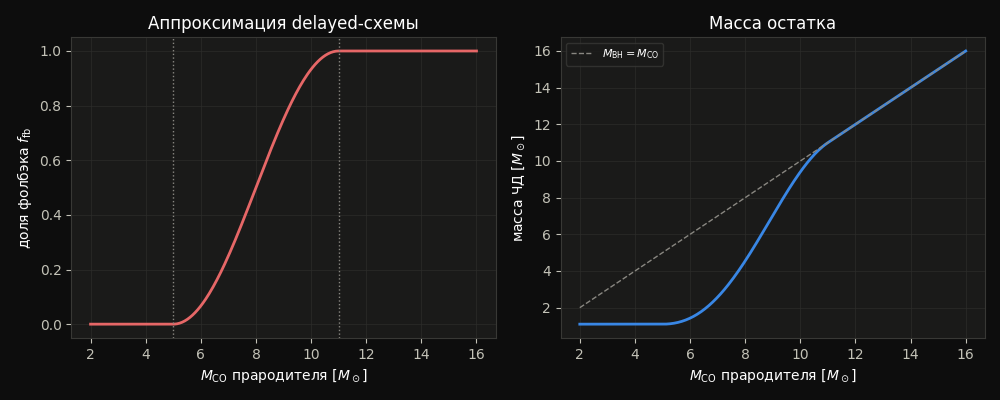

In [28]:
# Quick sanity-check plot: fallback fraction and resulting BH mass vs CO-core mass,
# so the shape of the (approximated) delayed-prescription ramp is visible at a glance.
M_CO_grid = np.linspace(2, 16, 300)
M_BH_grid, f_fb_grid = remnant_mass(M_CO_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax in axes:
    ax.grid(True, color=DARK["grid"], alpha=0.7)
axes[0].plot(M_CO_grid, f_fb_grid, color=DARK["red"], lw=2)
axes[0].axvline(M_CO_NO_FALLBACK, color=DARK["muted"], ls=":", lw=1)
axes[0].axvline(M_CO_FULL_FALLBACK, color=DARK["muted"], ls=":", lw=1)
axes[0].set_xlabel(r"$M_{\rm CO}$ прародителя [$M_\odot$]")
axes[0].set_ylabel(r"доля фолбэка $f_{\rm fb}$")
axes[0].set_title("Аппроксимация delayed-схемы")

axes[1].plot(M_CO_grid, M_BH_grid, color=DARK["blue"], lw=2)
axes[1].plot(M_CO_grid, M_CO_grid, color=DARK["muted"], ls="--", lw=1, label=r"$M_{\rm BH}=M_{\rm CO}$")
axes[1].set_xlabel(r"$M_{\rm CO}$ прародителя [$M_\odot$]")
axes[1].set_ylabel(r"масса ЧД [$M_\odot$]")
axes[1].legend(fontsize=8)
axes[1].set_title("Масса остатка")

fig.tight_layout()
plt.show()
